# 04 — Model Comparison

Doesn't retrain anything — just loads what `02_sarima.ipynb` and `03_lstm_tcn.ipynb` saved (`results/pred_*.pkl`) and produces:
1. the 9 actual-vs-predicted plots (3 squares x 3 models)
2. per-square MAE/MAPE/RMSE tables
3. a timing comparison table
4. one cross-model summary plot

Run the other two notebooks first if the pred files are missing.


In [1]:
import glob
import os
import pickle
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import common

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

meta = common.load_target_squares_meta()
squares = meta["top3_squares"]

PRED_PATTERN = re.compile(r"pred_(sarima|lstm|tcn)_sq(\d+)\.pkl")
MODEL_LABELS = {"sarima": "SARIMA", "lstm": "LSTM", "tcn": "TCN"}

results = {}
for path in sorted(glob.glob("results/pred_*_sq*.pkl")):
    match = PRED_PATTERN.search(os.path.basename(path))
    if not match:
        continue
    model_key, square_id = match.group(1), int(match.group(2))
    with open(path, "rb") as f:
        results[(MODEL_LABELS[model_key], square_id)] = pickle.load(f)

print(f"Loaded {len(results)} (model, square) result files: "
      f"{sorted(set(k[0] for k in results))} x {sorted(set(k[1] for k in results))}")
missing = [(m, sq) for m in ["SARIMA", "LSTM", "TCN"] for sq in squares if (m, sq) not in results]
if missing:
    print(f"WARNING: missing results for {missing} -- run the corresponding notebook(s) first.")

Loaded 9 (model, square) result files: ['LSTM', 'SARIMA', 'TCN'] x [5059, 5161, 5259]


## 1. Actual-vs-predicted plots (9 total: 3 squares x 3 models)


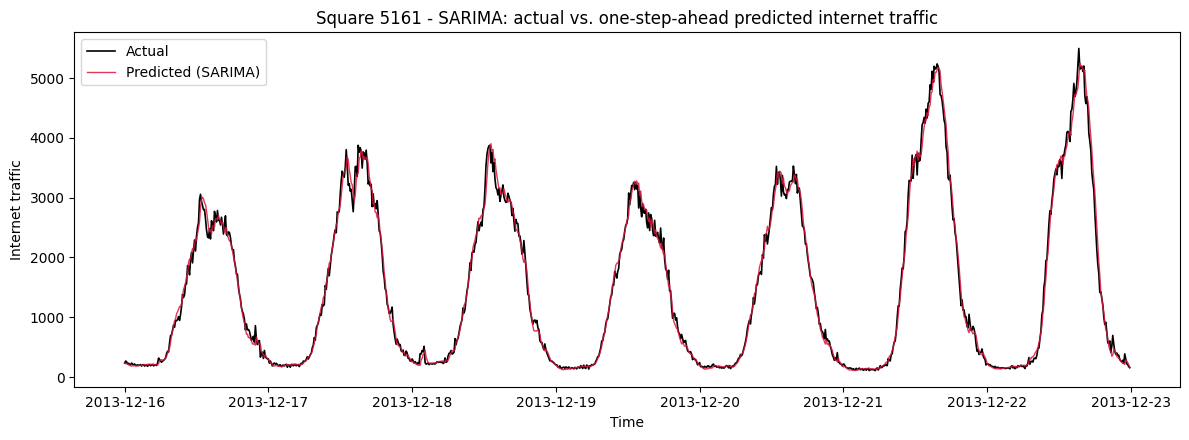

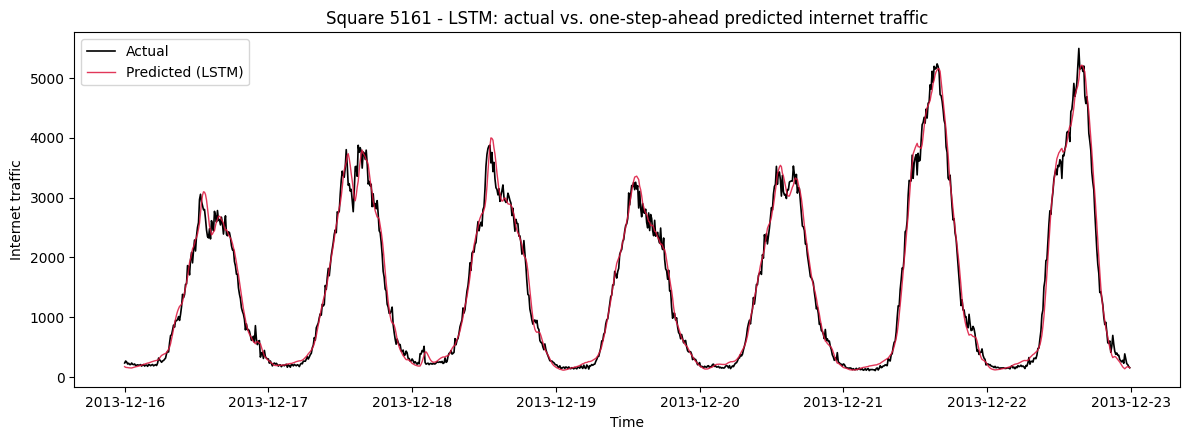

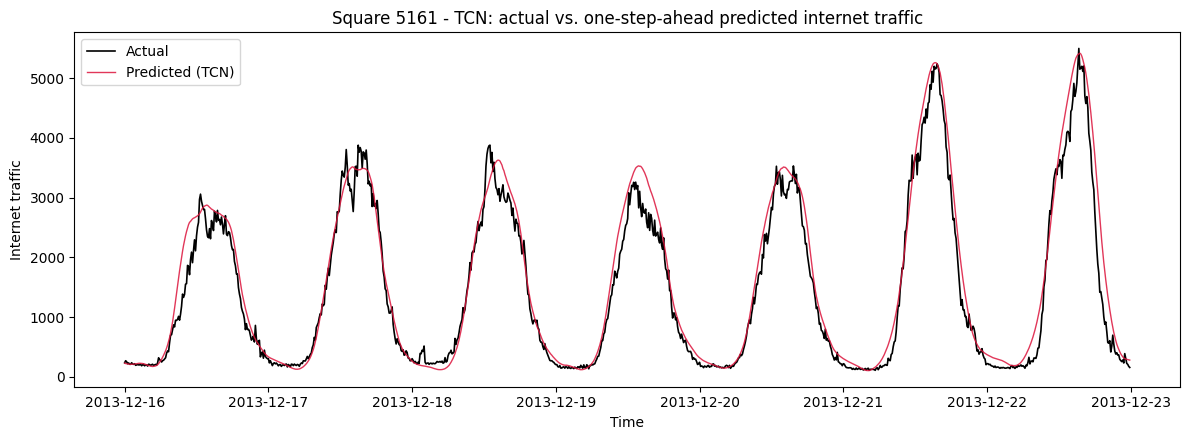

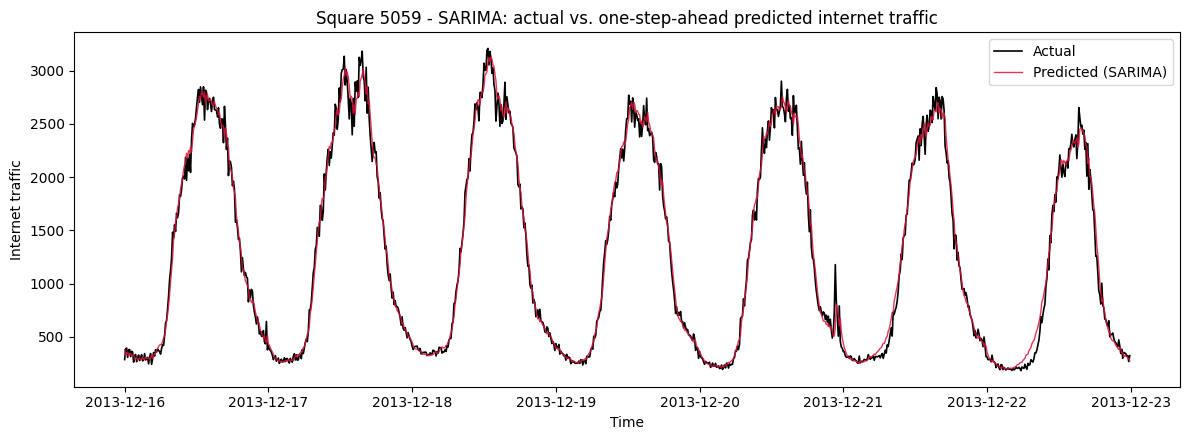

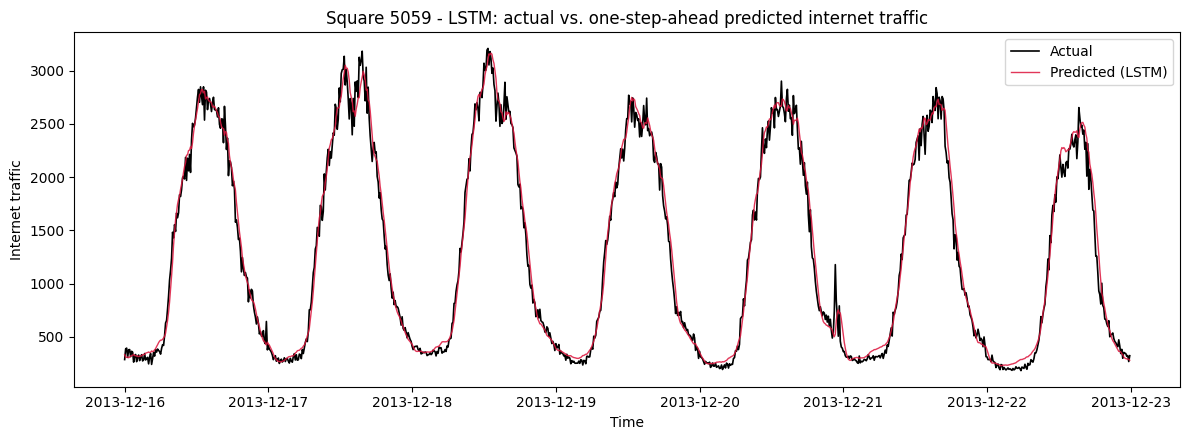

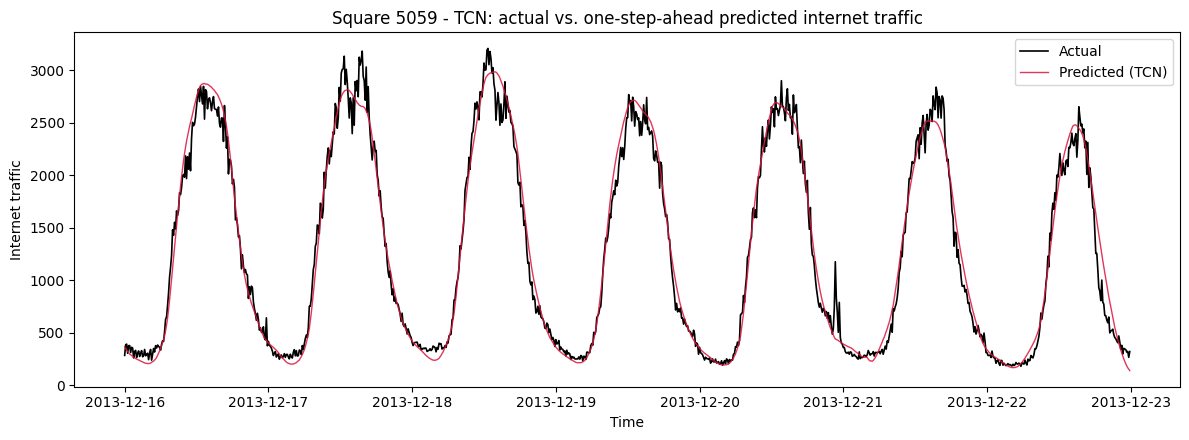

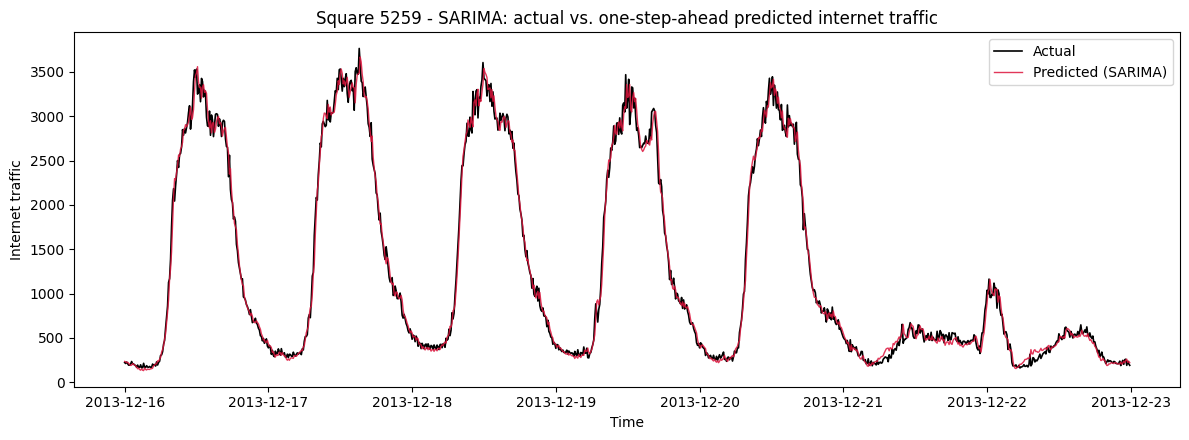

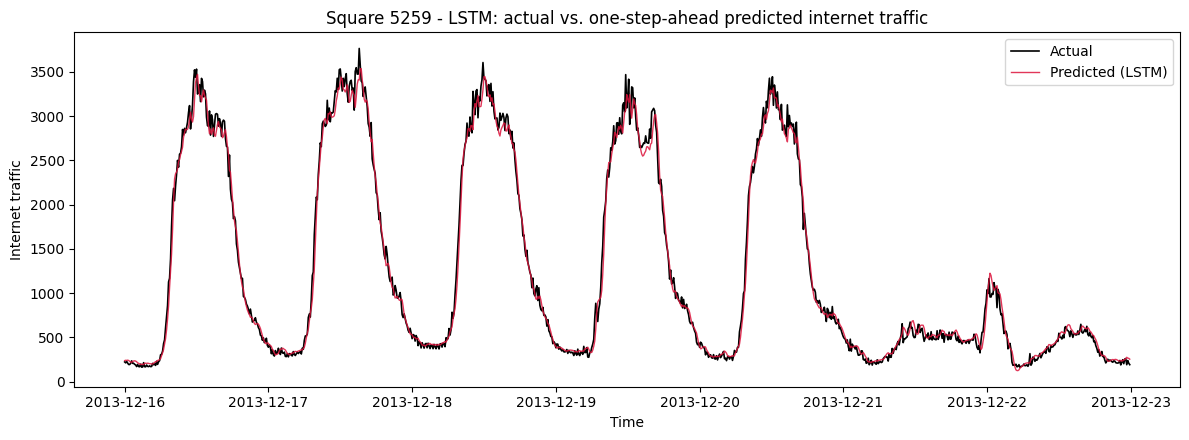

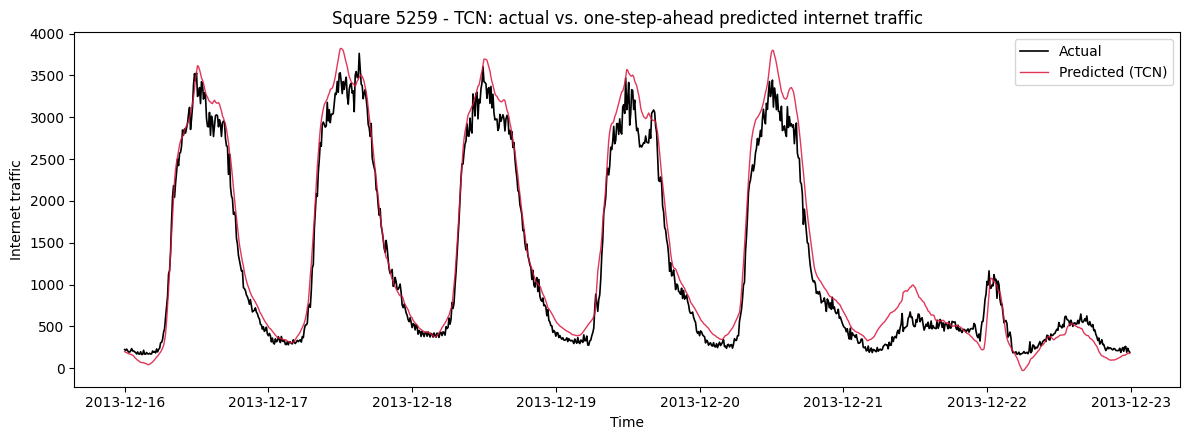

In [2]:
def plot_square_model(actual_index, actual_values, pred_index, preds, square_id, model_name):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(actual_index, actual_values, label="Actual", color="black", linewidth=1.2)
    ax.plot(pred_index, preds, label=f"Predicted ({model_name})", color="crimson", linewidth=1.0, alpha=0.85)
    ax.set_title(f"Square {square_id} - {model_name}: actual vs. one-step-ahead predicted internet traffic")
    ax.set_xlabel("Time"); ax.set_ylabel("Internet traffic")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"figures/pred_sq{square_id}_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


for square_id in squares:
    for model_name in ["SARIMA", "LSTM", "TCN"]:
        r = results.get((model_name, square_id))
        if r is None:
            continue
        plot_square_model(r["eval_index"], r["actual"], r["eval_index"], r["predictions"], square_id, model_name)

### 1b. Composite per-square comparison (all 3 models on one plot)

The 9 plots above are the required per-model evidence. These 3 composite figures (one per square, all 3 models overlaid) are just for the report, so it doesn't need to embed all 9 full-size images to make the same point.


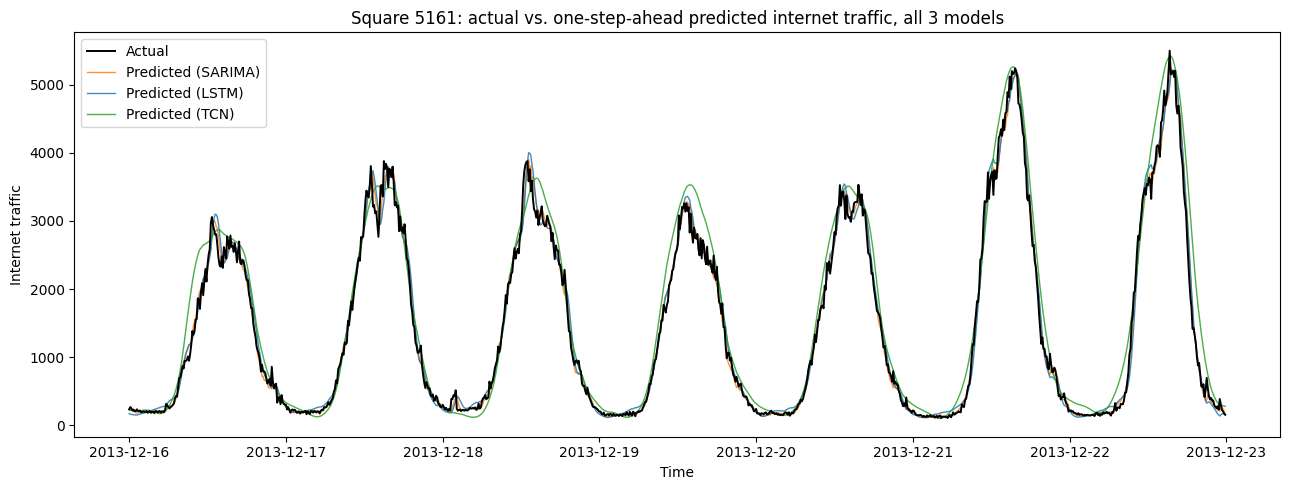

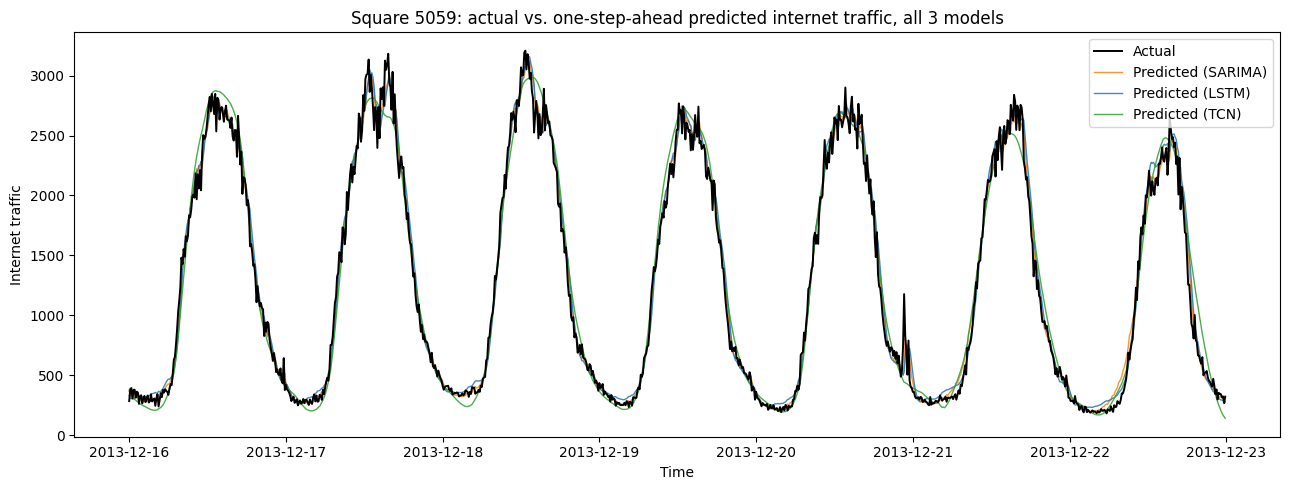

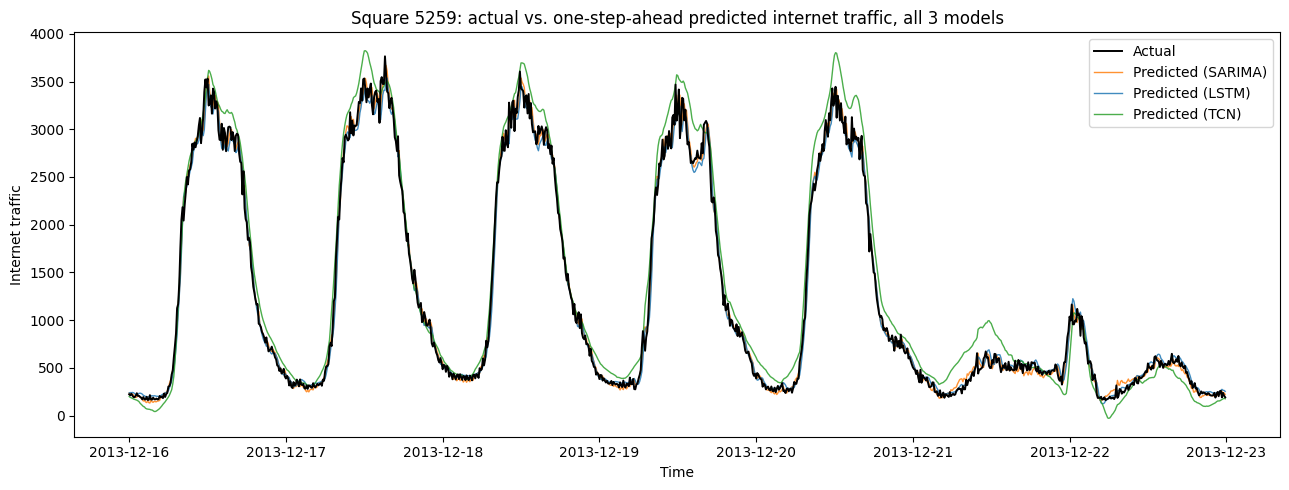

In [3]:
MODEL_COLORS = {"SARIMA": "tab:orange", "LSTM": "tab:blue", "TCN": "tab:green"}

for square_id in squares:
    fig, ax = plt.subplots(figsize=(13, 5))
    actual_plotted = False
    for model_name in ["SARIMA", "LSTM", "TCN"]:
        r = results.get((model_name, square_id))
        if r is None:
            continue
        if not actual_plotted:
            ax.plot(r["eval_index"], r["actual"], label="Actual", color="black", linewidth=1.4, zorder=5)
            actual_plotted = True
        ax.plot(r["eval_index"], r["predictions"], label=f"Predicted ({model_name})",
                color=MODEL_COLORS[model_name], linewidth=1.0, alpha=0.85)
    ax.set_title(f"Square {square_id}: actual vs. one-step-ahead predicted internet traffic, all 3 models")
    ax.set_xlabel("Time"); ax.set_ylabel("Internet traffic")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"figures/comparison_sq{square_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 2. Per-square performance tables (MAE / MAPE / RMSE)


In [4]:
for square_id in squares:
    print(f"--- Square {square_id} ---")
    rows = {model_name: results[(model_name, square_id)]["metrics"]
            for model_name in ["SARIMA", "LSTM", "TCN"] if (model_name, square_id) in results}
    table = pd.DataFrame(rows).T[["MAE", "MAPE", "RMSE"]].sort_values("RMSE")
    table.to_csv(f"results/model_performance_square_{square_id}.csv")
    display(table)

--- Square 5161 ---


,MAE,MAPE,RMSE
SARIMA,81.913476,8.436103,123.839350
LSTM,103.037021,13.521136,147.575479
TCN,201.037789,23.648699,289.201917


--- Square 5059 ---


,MAE,MAPE,RMSE
SARIMA,69.732807,7.685506,96.747916
LSTM,80.335012,9.367346,110.776044
TCN,99.038765,10.989539,135.564654


--- Square 5259 ---


,MAE,MAPE,RMSE
SARIMA,69.145732,8.456462,95.942475
LSTM,73.160441,8.379798,104.489785
TCN,160.848435,23.408123,202.016526


## 3. Timing comparison table


In [5]:
timing_rows = []
for (model_name, square_id), r in results.items():
    timing_rows.append({
        "square_id": square_id, "model": model_name,
        "fit_time_s": r["fit_time_s"], "predict_time_total_s": r["predict_time_s"],
        "predict_time_per_step_ms": r["predict_time_per_step_ms"],
    })
timing_df = pd.DataFrame(timing_rows).sort_values(["square_id", "model"]).reset_index(drop=True)
timing_df.to_csv("results/timing_stats.csv", index=False)
timing_df

,square_id,model,fit_time_s,predict_time_total_s,predict_time_per_step_ms
0,5059,LSTM,23.035711,0.173510,0.172133
1,5059,SARIMA,18.394675,84.626801,83.955159
2,5059,TCN,36.710295,0.407068,0.403838
3,5161,LSTM,18.581280,0.482906,0.479073
4,5161,SARIMA,2.387218,72.663652,72.086956
5,5161,TCN,27.430877,0.322793,0.320231
6,5259,LSTM,26.167913,0.212903,0.211213
7,5259,SARIMA,10.854849,70.027027,69.471257
8,5259,TCN,75.155090,0.390897,0.387794


## 4. Cross-model, cross-square summary


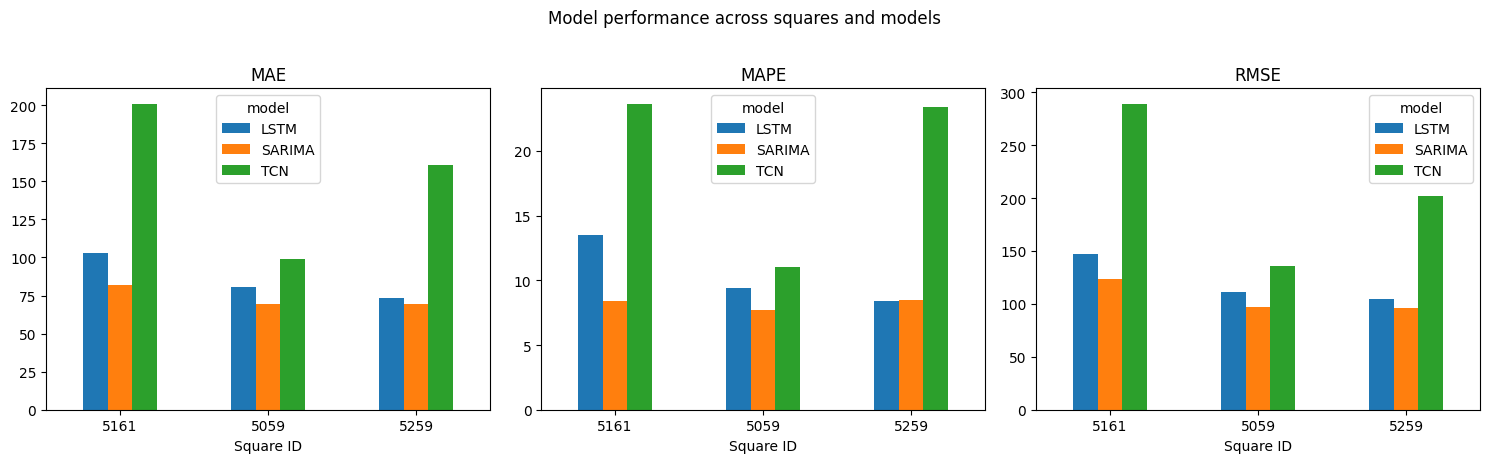

,square_id,model,MAE,RMSE,MAPE
0,5059,LSTM,80.335012,110.776044,9.367346
1,5161,LSTM,103.037021,147.575479,13.521136
2,5259,LSTM,73.160441,104.489785,8.379798
3,5059,SARIMA,69.732807,96.747916,7.685506
4,5161,SARIMA,81.913476,123.839350,8.436103
5,5259,SARIMA,69.145732,95.942475,8.456462
6,5059,TCN,99.038765,135.564654,10.989539
7,5161,TCN,201.037789,289.201917,23.648699
8,5259,TCN,160.848435,202.016526,23.408123


In [6]:
comparison_rows = [{"square_id": sq, "model": model_name, **r["metrics"]}
                    for (model_name, sq), r in results.items()]
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("results/model_performance_comparison_all.csv", index=False)

metrics = ["MAE", "MAPE", "RMSE"]
fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4.5))
for ax, metric in zip(axes, metrics):
    pivot = comparison_df.pivot(index="square_id", columns="model", values=metric).loc[squares]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Square ID")
    ax.tick_params(axis="x", rotation=0)
fig.suptitle("Model performance across squares and models", y=1.02)
fig.tight_layout()
fig.savefig("figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

comparison_df

## 5. Discussion

The research question: how do SARIMA, LSTM, and TCN compare for one-step-ahead forecasting, and does the ranking hold across squares with different traffic characteristics? Worth checking:
- Which model wins on RMSE/MAE, and does that match who wins on MAPE?
- Does the ranking change between squares — and if so, does that square look different in the EDA (scale, volatility)?
- Is the most accurate model also the most expensive to train?
- Any failure cases in the plots above — spots where a model visibly lags or overshoots, especially around square 5161's spikes? That's exactly where aggregate metrics can hide a real weakness.
